# 재구매 예측 모델 

> **목적**: DA에서 발견한 행동 기반 인사이트를 피처로 활용해 재구매 여부를 예측하고,
> CRM 발송 비용을 줄이면서 고가 이탈 고객을 최대한 포착하는 최적 타겟을 선정한다.

| 항목 | 내용 |
|---|---|
| 분석 대상 | 332,125명 (N=18일 이상 관측 가능) |
| 타겟 변수 | 재구매 여부 (1=재구매, 0=미재구매) |
| 예측 시점 | 분석 성격: 과거 구매 및 재구매 전 행동으로 재구매 여부를 분류하고 CRM 타겟 우선순위를 탐색한다. 조기 재구매자를 포함 |
| 연결 파일 | 프로젝트3-퍼널이탈분석_v2.ipynb (DA 파트) |

## 0. 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


df1 = pd.read_pickle("clean_events.pkl")

print('데이터 로드 완료')
print(f'전체 이벤트 수: {len(df1):,}')
print(f'컬럼: {list(df1.columns)}')

데이터 로드 완료
전체 이벤트 수: 63,646,952
컬럼: ['event_time', 'event_type', 'product_id', 'category_id', 'category_code', 'brand', 'price', 'user_id', 'user_session']


## 1. 분석 대상 확정 및 타겟 변수 생성

> DA와 동일하게 N=18일 이상 관측 가능한 유저만 분석 대상으로 제한한다.
> 관측 기간이 짧은 유저는 재구매 여부를 확인할 시간이 부족해서
> 타겟 변수가 구조적으로 0(미재구매)으로 편향된다 — 우측 절단 문제.

In [2]:
# 데이터 기간 마지막 날짜 확인
df1['event_time'] = pd.to_datetime(df1['event_time'])
last_date = df1['event_time'].max()
print(f'데이터 마지막 날짜: {last_date}')

# 구매 이벤트만 추출
purchases = df1[df1['event_type'] == 'purchase'].copy()

# 유저별 첫 구매 시점 계산
first_purchase = (
    purchases.groupby('user_id')['event_time']
    .min()
    .reset_index()
    .rename(columns={'event_time': 'first_purchase_time'})
)

# N=18일 이상 관측 가능한 유저 필터링
# 첫 구매 후 18일 이상 데이터가 남아있어야 재구매 여부 확인 가능
first_purchase['days_remaining'] = (
    last_date - first_purchase['first_purchase_time']
).dt.days

analysis_users = first_purchase[first_purchase['days_remaining'] >= 18].copy()
print(f'분석 대상 유저 수: {len(analysis_users):,}명')

데이터 마지막 날짜: 2019-11-30 23:59:59
분석 대상 유저 수: 332,125명


In [3]:
# 타겟 변수 생성: 재구매 여부 (1=재구매, 0=미재구매)
# 첫 구매 후 18일 이내에 두 번째 구매가 있으면 재구매(1)

# 유저별 두 번째 구매 시점 계산
purchase_counts = (
    purchases.groupby('user_id')
    .apply(lambda x: x.sort_values('event_time')['event_time'].iloc[1]
           if len(x) >= 2 else pd.NaT)
    .reset_index()
    .rename(columns={0: 'second_purchase_time'})
)

analysis_users = analysis_users.merge(purchase_counts, on='user_id', how='left')

# 첫 구매 후 18일 이내 재구매 여부
analysis_users['days_to_repurchase'] = (
    analysis_users['second_purchase_time'] - analysis_users['first_purchase_time']
).dt.days

# days_to_repurchase = 0 (동일 날짜 재구매)도 재구매로 포함
analysis_users['repurchase'] = (
    analysis_users['days_to_repurchase'] <= 18
).astype(int)

print('=' * 50)
print('타겟 변수 분포')
print('=' * 50)
counts = analysis_users['repurchase'].value_counts()
print(f'재구매(1): {counts.get(1, 0):,}명 ({counts.get(1, 0)/len(analysis_users)*100:.1f}%)')
print(f'미재구매(0): {counts.get(0, 0):,}명 ({counts.get(0, 0)/len(analysis_users)*100:.1f}%)')

타겟 변수 분포
재구매(1): 117,868명 (35.5%)
미재구매(0): 214,257명 (64.5%)


## 2. 피처 엔지니어링

> 원본 데이터는 이벤트 로그 형태 (행 하나 = 행동 하나).
> 모델은 유저 한 명당 한 행의 데이터가 필요하므로
> 이벤트 로그를 유저 단위로 집계해서 피처를 만들어야 한다.

**피처 선택 기준**
- DA 효과크기 검증 변수 → 반드시 포함
- DA 방향 확인 변수 → 포함 (조합 가능성)
- 도메인 기반 변수 → 판단해서 포함

### 2-1. Pre-purchase 피처 (첫 구매 이전 행동)

In [4]:
# 분석 대상 유저의 첫 구매 이전 이벤트만 추출
# 왜: 첫 구매 이전 행동만 pre-purchase 피처로 사용 가능

pre_events = df1.merge(
    analysis_users[['user_id', 'first_purchase_time']],
    on='user_id'
)
pre_events = pre_events[pre_events['event_time'] < pre_events['first_purchase_time']]

# 첫 구매 이전 view 횟수 (탐색 깊이)
pre_views = (
    pre_events[pre_events['event_type'] == 'view']
    .groupby('user_id').size()
    .reset_index()
    .rename(columns={0: 'pre_view_count'})
)

# 첫 구매 이전 cart 횟수 (구매 신중도)
pre_carts = (
    pre_events[pre_events['event_type'] == 'cart']
    .groupby('user_id').size()
    .reset_index()
    .rename(columns={0: 'pre_cart_count'})
)

# 첫 구매 카테고리 + 가격 (도메인 기반)
first_purchase_info = (
    purchases.merge(analysis_users[['user_id', 'first_purchase_time']], on='user_id')
    .query('event_time == first_purchase_time')
    .groupby('user_id')
    .first()
    .reset_index()
    [['user_id', 'category_code', 'price']]
    .rename(columns={'category_code': 'first_category', 'price': 'first_purchase_price'})
)

# 첫 구매까지 걸린 시간 (도메인 기반)
first_event_time = (
    df1.groupby('user_id')['event_time'].min()
    .reset_index()
    .rename(columns={'event_time': 'first_event_time'})
)

analysis_users = analysis_users.merge(first_event_time, on='user_id', how='left')
analysis_users['days_to_first_purchase'] = (
    analysis_users['first_purchase_time'] - analysis_users['first_event_time']
).dt.days

print('Pre-purchase 피처 생성 완료')

Pre-purchase 피처 생성 완료


### 2-2. Post-purchase 피처 (첫 구매 후 7일 이내 행동)

> **왜 7일인가**
> 타겟 기간(18일)과 관측 창이 겹치면 Data Leakage 발생.
> 7일 관측 후 남은 기간(최소 11일)에 재구매할지를 예측하는 구조.
> DA에서 검증된 가장 강력한 신호(V=0.505)가 post-purchase 행동이므로
> 7일이라는 짧은 창에서도 충분한 신호를 포착할 수 있다.

In [5]:
# 경과 일수 1~7에 해당하는 행동: 첫 구매 후 24시간 이상~8일 미만
# 왜: 예측 시점을 첫 구매 후 7일로 설정했기 때문
# purchase 이벤트를 제외하고 두 번째 purchase 이벤트 이전 행동만 집계한다
#        → 재구매가 이미 일어난 뒤의 행동을 "재구매 원인"으로 잘못 카운트하는 것 방지

post_events = df1.merge(
    analysis_users[['user_id', 'first_purchase_time', 'second_purchase_time']],
    on='user_id'
)

post_events['days_after_purchase'] = (
    post_events['event_time'] - post_events['first_purchase_time']
).dt.days

# 첫 구매 후 1~7일 이내 이벤트만 (당일 제외, 재구매 이벤트 제외)
# [수정] + 두 번째 구매가 있다면 그보다 반드시 이전이어야 함
post_events = post_events[
    (post_events['days_after_purchase'] > 0) &
    (post_events['days_after_purchase'] <= 7) &
    (post_events['event_type'] != 'purchase') &
    (
        post_events['second_purchase_time'].isna() |
        (post_events['event_time'] < post_events['second_purchase_time'])
    )
]

# 7일 이내 view 여부
post_view_yn = (
    post_events[post_events['event_type'] == 'view']
    .groupby('user_id').size()
    .reset_index()
    .rename(columns={0: 'post_view_count'})
)
post_view_yn['post_view_yn'] = 1

# 7일 이내 cart 재추가 여부
post_cart_yn = (
    post_events[post_events['event_type'] == 'cart']
    .groupby('user_id').size()
    .reset_index()
    .rename(columns={0: 'post_cart_count'})
)
post_cart_yn['post_cart_yn'] = 1

# 7일 이내 동일 상품 재조회 여부
first_product = (
    purchases.merge(analysis_users[['user_id', 'first_purchase_time']], on='user_id')
    .query('event_time == first_purchase_time')
    .groupby('user_id')['product_id'].first()
    .reset_index()
    .rename(columns={'product_id': 'first_product_id'})
)

repeat_view = post_events.merge(first_product, on='user_id', how='left')
repeat_view = repeat_view[
    (repeat_view['event_type'] == 'view') &
    (repeat_view['product_id'] == repeat_view['first_product_id'])
]
repeat_view_yn = (
    repeat_view.groupby('user_id').size()
    .reset_index()
    .rename(columns={0: 'repeat_view_count'})
)
repeat_view_yn['repeat_view_yn'] = 1

print('Post-purchase 피처 생성 완료 (재구매 이전 시점으로 제약)')

Post-purchase 피처 생성 완료 (재구매 이전 시점으로 제약)


### 2-3. 피처 통합

In [6]:
# 모든 피처를 유저 단위로 합치기
# 왜 left join: 분석 대상 유저 기준으로 합쳐야 하고
#               행동이 없는 경우 0으로 채워야 하기 때문

feature_df = analysis_users[[
    'user_id', 'repurchase', 'days_to_first_purchase'
]].copy()

# Pre-purchase 피처 합치기
feature_df = feature_df.merge(pre_views, on='user_id', how='left')
feature_df = feature_df.merge(pre_carts, on='user_id', how='left')
feature_df = feature_df.merge(first_purchase_info, on='user_id', how='left')

# Post-purchase 피처 합치기
feature_df = feature_df.merge(
    post_view_yn[['user_id', 'post_view_yn', 'post_view_count']],
    on='user_id', how='left'
)
feature_df = feature_df.merge(
    post_cart_yn[['user_id', 'post_cart_yn', 'post_cart_count']],
    on='user_id', how='left'
)
feature_df = feature_df.merge(
    repeat_view_yn[['user_id', 'repeat_view_yn']],
    on='user_id', how='left'
)

# 결측값 처리
# 왜: 행동이 없는 경우 NaN → 0으로 채움 (행동 없음 = 0)
fill_zero_cols = [
    'pre_view_count', 'pre_cart_count',
    'post_view_yn', 'post_view_count',
    'post_cart_yn', 'post_cart_count',
    'repeat_view_yn'
]
feature_df[fill_zero_cols] = feature_df[fill_zero_cols].fillna(0)

# 카테고리 인코딩 (문자열 → 숫자)
# 왜: 모델은 숫자만 입력받기 때문
feature_df['first_category'] = feature_df['first_category'].fillna('unknown')
feature_df['first_category_encoded'] = pd.Categorical(feature_df['first_category']).codes

print('=' * 50)
print('피처 데이터프레임 완성')
print('=' * 50)
print(f'유저 수: {len(feature_df):,}명')
print(f'피처 수: {len(feature_df.columns) - 2}개 (user_id, repurchase 제외)')
print()
print(feature_df.head())

피처 데이터프레임 완성
유저 수: 332,125명
피처 수: 11개 (user_id, repurchase 제외)

     user_id  repurchase  days_to_first_purchase  pre_view_count  \
0  225644257           0                       3             6.0   
1  253299396           0                       0             3.0   
2  299358698           0                       0             3.0   
3  303160429           0                       8             2.0   
4  307138432           0                       0             4.0   

   pre_cart_count            first_category  first_purchase_price  \
0             2.0  computers.components.hdd                 40.91   
1             0.0   appliances.kitchen.hood                246.85   
2             1.0    electronics.smartphone                154.19   
3             0.0        electronics.clocks                340.59   
4             1.0    electronics.smartphone                106.57   

   post_view_yn  post_view_count  post_cart_yn  post_cart_count  \
0           0.0              0.0           0.

In [26]:
print('post_view_yn 합계:', feature_df['post_view_yn'].sum())
print('post_cart_yn 합계:', feature_df['post_cart_yn'].sum())
print('repeat_view_yn 합계:', feature_df['repeat_view_yn'].sum())

post_view_yn 합계: 104420.0
post_cart_yn 합계: 31859.0
repeat_view_yn 합계: 43008.0


In [8]:
# import pickle

# feature_df.to_pickle('feature_df.pkl')

## 3. 모델 학습 — Logistic Regression

> **왜 Logistic Regression부터 시작하는가**
>
> 1. **베이스라인 확보**: Random Forest 같은 복잡한 모델이 얼마나 더 나은가를 측정하려면 비교 기준이 필요하다.
> 2. **해석 가능성**: 각 피처의 계수(coefficient)로 어떤 변수가 재구매에 얼마나 영향을 주는가를 수치로 설명할 수 있다.
> 3. **안정성**: 피처 11개, 표본 33만명 규모에서 LR은 과적합 없이 안정적으로 수렴한다.

### 3-1. 데이터 준비 (Train/Test Split + 스케일링)

In [9]:
import pickle
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 저장된 피처 데이터 로드
# feature_df = pd.read_pickle('feature_df.pkl')

# 피처와 타겟 분리
# first_category는 인코딩된 컬럼(first_category_encoded)으로 대체됨
X = feature_df.drop(columns=['repurchase', 'first_category','user_id'])
y = feature_df['repurchase']

print('피처 목록:', list(X.columns))
print('전체 샘플 수:', len(X), '명')
print('재구매(1):', y.sum(), '명 (', round(y.mean()*100,1), '%)')
print('미재구매(0):', int((~y.astype(bool)).sum()), '명 (', round((1-y.mean())*100,1), '%)')

# Train/Test Split (80:20, stratify로 클래스 비율 유지)
# stratify 이유: 35:65 불균형이 있어서 분할 후에도 동일 비율 유지 필요
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train:', len(X_train), '명 | Test:', len(X_test), '명')

# 스케일링 (StandardScaler)
# 이유: LR은 피처 스케일에 민감.
# days_to_first_purchase(최대 수백)와 post_view_yn(0/1)의 스케일 차이가 크면 계수 해석이 어려움
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # test는 train 기준으로만 변환

print('스케일링 완료')

피처 목록: ['days_to_first_purchase', 'pre_view_count', 'pre_cart_count', 'first_purchase_price', 'post_view_yn', 'post_view_count', 'post_cart_yn', 'post_cart_count', 'repeat_view_yn', 'first_category_encoded']
전체 샘플 수: 332125 명
재구매(1): 117868 명 ( 35.5 %)
미재구매(0): 214257 명 ( 64.5 %)
Train: 265700 명 | Test: 66425 명
스케일링 완료


### 3-2. Logistic Regression 학습

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# 두 버전 비교: default vs balanced
# class_weight='balanced': 클래스 불균형(35:65) 보정
# 35:65는 심각하지 않지만 balanced 적용 시 소수 클래스(재구매) Recall이 올라감
lr_default = LogisticRegression(random_state=42, max_iter=1000)
lr_balanced = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

lr_default.fit(X_train_scaled, y_train)
lr_balanced.fit(X_train_scaled, y_train)

print('=== Logistic Regression (default) ===')
y_pred_default = lr_default.predict(X_test_scaled)
print(classification_report(y_test, y_pred_default, target_names=['미재구매(0)', '재구매(1)']))

print('=== Logistic Regression (balanced) ===')
y_pred_balanced = lr_balanced.predict(X_test_scaled)
print(classification_report(y_test, y_pred_balanced, target_names=['미재구매(0)', '재구매(1)']))

auc_default = roc_auc_score(y_test, lr_default.predict_proba(X_test_scaled)[:,1])
auc_balanced = roc_auc_score(y_test, lr_balanced.predict_proba(X_test_scaled)[:,1])
print('ROC-AUC (default):', round(auc_default, 4))
print('ROC-AUC (balanced):', round(auc_balanced, 4))

=== Logistic Regression (default) ===
              precision    recall  f1-score   support

     미재구매(0)       0.69      0.96      0.80     42851
      재구매(1)       0.75      0.20      0.32     23574

    accuracy                           0.69     66425
   macro avg       0.72      0.58      0.56     66425
weighted avg       0.71      0.69      0.63     66425

=== Logistic Regression (balanced) ===
              precision    recall  f1-score   support

     미재구매(0)       0.70      0.84      0.77     42851
      재구매(1)       0.55      0.35      0.43     23574

    accuracy                           0.67     66425
   macro avg       0.62      0.60      0.60     66425
weighted avg       0.65      0.67      0.65     66425

ROC-AUC (default): 0.6305
ROC-AUC (balanced): 0.6307


### 3-3. 피처 계수 해석

> LR의 계수(coefficient)는 각 피처가 재구매 확률에 미치는 방향과 크기를 나타낸다.
> 스케일링 후 계수이므로 피처 간 직접 비교 가능 (값이 클수록 재구매에 강한 양의 영향).

=== 재구매에 영향을 주는 피처 (계수 기준, default 모델) ===
               feature  coefficient
          post_cart_yn     0.640606
  first_purchase_price     0.165352
        pre_view_count     0.040859
first_category_encoded     0.035691
          post_view_yn    -0.027043
        repeat_view_yn    -0.029246
       post_cart_count    -0.038894
        pre_cart_count    -0.046446
days_to_first_purchase    -0.056105
       post_view_count    -0.088430


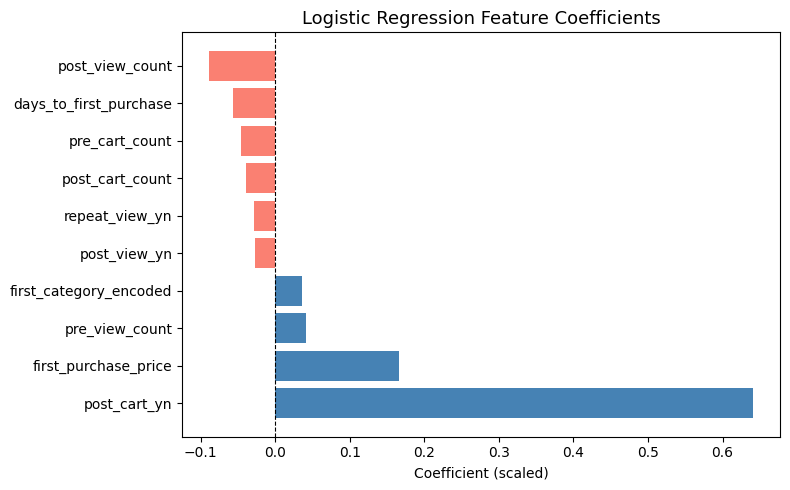

lr_coefficients.png 저장 완료


In [11]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr_default.coef_[0]
}).sort_values('coefficient', ascending=False)

print('=== 재구매에 영향을 주는 피처 (계수 기준, default 모델) ===')
print(coef_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if c > 0 else 'salmon' for c in coef_df['coefficient']]
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Logistic Regression Feature Coefficients', fontsize=13)
ax.set_xlabel('Coefficient (scaled)')
plt.tight_layout()
plt.savefig('lr_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()
print('lr_coefficients.png 저장 완료')

### 3-4. 비즈니스 관점 모델 평가

> **Precision vs Recall 선택 기준**
>
> 이 모델의 목적: 재구매 안 할 것 같은 사람(0 예측)에게 CRM 발송
>
> | 지표 | 의미 | 비즈니스 영향 |
> |---|---|---|
> | Precision (0 클래스) | CRM 발송 대상 중 실제 미재구매 비율 | 낮으면 → 재구매할 사람에게 불필요한 CRM 발송 (비용 낭비) |
> | Recall (0 클래스) | 실제 미재구매자 중 CRM으로 잡은 비율 | 낮으면 → 이탈할 사람을 놓침 (매출 기회 손실) |
>
> 이 프로젝트 목적: 규칙 기반 214,188명보다 발송수를 줄이면서 불필요한 CRM 비용을 낮추는 것
> → **Precision 우선** (불필요한 CRM을 줄이는 방향)
> → Section 4에서 RF·XGBoost와 동일 기준으로 비교한다.

## 4. 모델 확장 — Random Forest + XGBoost

> **LR 결과에서 확인된 한계**
>
> 1. **재구매(1) Recall 0.20**: 실제 재구매할 사람의 80%를 미재구매로 잘못 예측
>    - LR은 선형 결정 경계만 학습 → 행동 피처 간 비선형 상호작용을 포착하지 못함
>    - 피처 정제(재구매 이전 시점으로 제약) 이후 유효 신호가 post_cart_yn,
>      first_purchase_price 등 소수로 좁혀지면서, 남은 피처들 간의 비선형
>      조합 패턴을 잡아낼 수 있는 모델이 더욱 중요해짐
>
> **Random Forest**: 다수의 결정 트리 앙상블 → 비선형 패턴 포착 가능
> **XGBoost**: 순차적 트리 부스팅 → RF보다 일반적으로 높은 성능, 피처 중요도 제공

In [12]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
y_prob_rf = rf.predict_proba(X_test_scaled)[:, 1]

print('=== Random Forest ===')
print(classification_report(y_test, y_pred_rf, target_names=['미재구매(0)', '재구매(1)']))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob_rf), 4))

=== Random Forest ===
              precision    recall  f1-score   support

     미재구매(0)       0.72      0.77      0.74     42851
      재구매(1)       0.52      0.46      0.49     23574

    accuracy                           0.66     66425
   macro avg       0.62      0.61      0.62     66425
weighted avg       0.65      0.66      0.65     66425

ROC-AUC: 0.6629


In [13]:
from xgboost import XGBClassifier

# scale_pos_weight: 미재구매/재구매 비율로 불균형 보정
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_pos,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train_scaled, y_train)

y_pred_xgb = xgb.predict(X_test_scaled)
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:, 1]

print('=== XGBoost ===')
print(classification_report(y_test, y_pred_xgb, target_names=['미재구매(0)', '재구매(1)']))
print('ROC-AUC:', round(roc_auc_score(y_test, y_prob_xgb), 4))

=== XGBoost ===
              precision    recall  f1-score   support

     미재구매(0)       0.69      0.96      0.80     42851
      재구매(1)       0.74      0.22      0.34     23574

    accuracy                           0.70     66425
   macro avg       0.72      0.59      0.57     66425
weighted avg       0.71      0.70      0.64     66425

ROC-AUC: 0.6647


In [27]:
from sklearn.metrics import precision_score, recall_score, roc_auc_score

models = {
    'LR': (y_pred_default, lr_default.predict_proba(X_test_scaled)[:, 1]),
    'RF': (y_pred_rf, y_prob_rf),
    'XGBoost': (y_pred_xgb, y_prob_xgb)
}

print('=== 1차 비교: 예측 성능 ===')
print(f"{'':10} {'ROC-AUC':>10} {'Precision':>10} {'Recall':>10}")
print('-' * 45)

perf = {}
for name, (y_pred, y_prob) in models.items():
    roc  = roc_auc_score(y_test, y_prob)
    prec = precision_score(y_test, y_pred, pos_label=0)
    rec  = recall_score(y_test, y_pred, pos_label=0)
    perf[name] = {'roc': roc, 'prec': prec, 'rec': rec, 'prob': y_prob}
    print(f"{name:10} {roc:>10.4f} {prec:>10.4f} {rec:>10.4f}")

print('\n* Precision/Recall은 미재구매(0) 클래스 기준')
print('* ROC-AUC: LR(0.63) < RF(0.66) ≈ XGBoost(0.66) → LR만 상대적으로 저조,')
print('  트리 모델이 소수 잔존 피처의 비선형 조합을 더 잘 활용')
print('* RF: Precision 최고, Recall 상대적 낮음 → 더 적게 더 정확하게 타겟팅 → 발송수 절감 목적과 일치')

=== 1차 비교: 예측 성능 ===
              ROC-AUC  Precision     Recall
---------------------------------------------
LR             0.6305     0.6871     0.9633
RF             0.6629     0.7211     0.7693
XGBoost        0.6647     0.6915     0.9563

* Precision/Recall은 미재구매(0) 클래스 기준
* ROC-AUC: LR(0.63) < RF(0.66) ≈ XGBoost(0.66) → LR만 상대적으로 저조,
  트리 모델이 소수 잔존 피처의 비선형 조합을 더 잘 활용
* RF: Precision 최고, Recall 상대적 낮음 → 더 적게 더 정확하게 타겟팅 → 발송수 절감 목적과 일치


## 5. CRM Score 계산 및 비즈니스 성과 비교

### 5-1. CRM Score 정의

> **CRM Score = 1 - P(재구매)**
>
> - 이탈 방지 CRM이 목적 → 이탈 위험도만으로 타겟 선정
> - Score 높은 사람 = 재구매 가능성 낮은 사람 → CRM 최우선 타겟
> - 이 단계에서는 모델 간 성능 비교를 위해 이탈 위험도 단독 스코어 사용
> - Section 6에서 구매금액을 결합한 Combined Score로 최적 발송 타겟 비율 선정
>
> DA 목표와의 연결: 규칙 기반 214,188명보다 적은 발송으로 이탈 고객 가치를 최대한 포착한다

In [15]:
X_test_df = X_test.copy().reset_index(drop=True)
y_test_arr = y_test.values

crm_results = {}

for name, (y_pred, y_prob) in models.items():
    df = pd.DataFrame({
        'p_repurchase': y_prob,
        'first_purchase_price': X_test_df['first_purchase_price'].values,
        'actual': y_test_arr
    })
    df['crm_score'] = 1 - df['p_repurchase']
    df = df.sort_values('crm_score', ascending=False).reset_index(drop=True)
    crm_results[name] = df

print('CRM Score = 1 - P(재구매) 계산 완료')
print('샘플 (RF 상위 10건):')
print(crm_results['RF'][['p_repurchase', 'crm_score', 'actual']].head(10))
print('\n상위 10건 중 실제 미재구매(0) 비율:',
      round((crm_results['RF'].head(10)['actual'] == 0).mean(), 3))

CRM Score = 1 - P(재구매) 계산 완료
샘플 (RF 상위 10건):
   p_repurchase  crm_score  actual
0      0.131719   0.868281       0
1      0.133620   0.866380       0
2      0.136064   0.863936       0
3      0.137410   0.862590       0
4      0.138465   0.861535       1
5      0.138477   0.861523       1
6      0.142499   0.857501       0
7      0.143662   0.856338       1
8      0.145461   0.854539       0
9      0.147687   0.852313       0

상위 10건 중 실제 미재구매(0) 비율: 0.7


In [16]:
# 이미 저장 완료 — 재실행 불필요
# rf_full_results.pkl: Section 6에서 전체 332,125명 기준으로 별도 생성
#crm_results['RF'].to_pickle('rf_crm_results.pkl')
#print("저장 완료:", crm_results['RF'].shape)
# crm_results['LR'].to_pickle('lr_crm_results.pkl')
# crm_results['XGBoost'].to_pickle('xgb_crm_results.pkl')

In [17]:
# 한글 폰트 설정 (Windows)

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

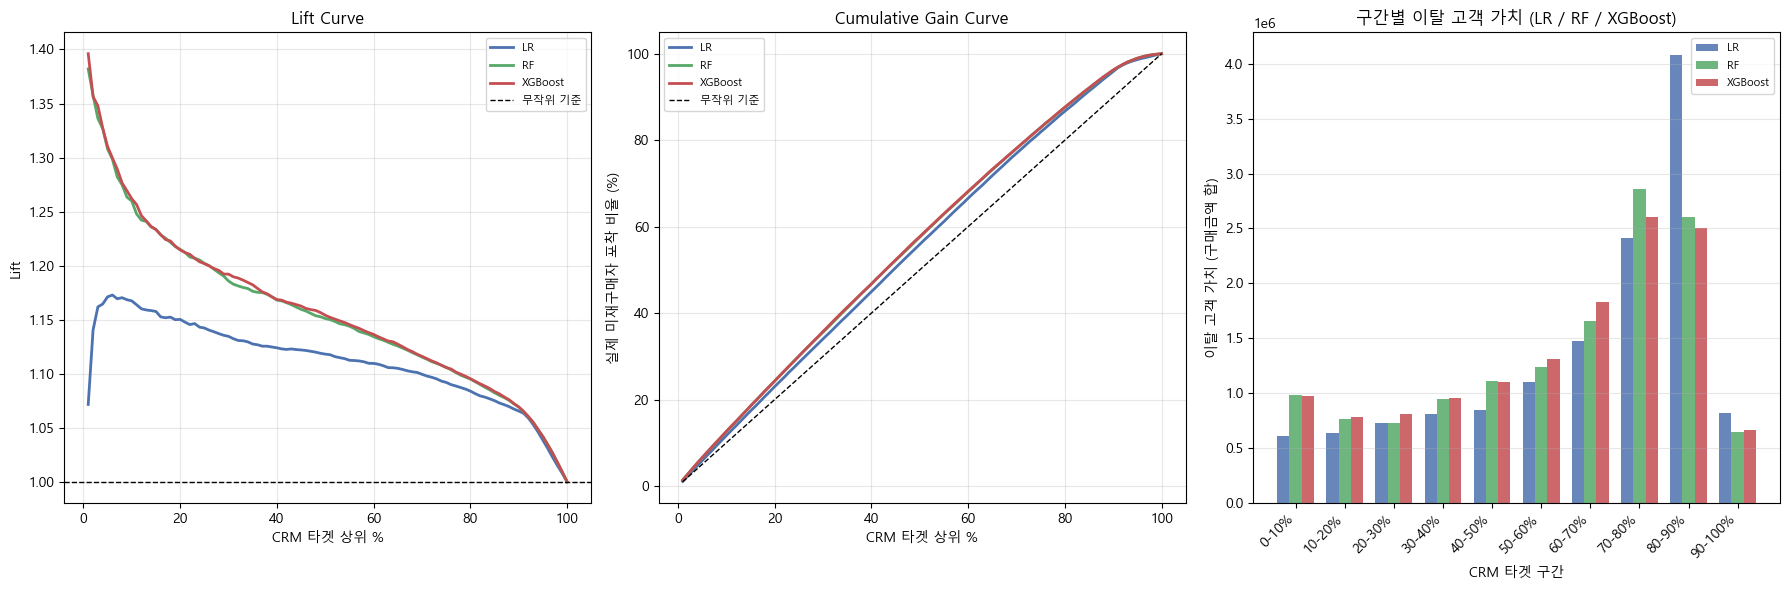

저장 완료: crm_comparison_charts.png


In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

n_test = len(y_test_arr)
total_churn = (y_test_arr == 0).sum()
base_rate = total_churn / n_test * 100
x_range = np.arange(1, 101)

colors = {'LR': '#4C72B0', 'RF': '#55A868', 'XGBoost': '#C44E52'}

# ── 차트 1: Lift Curve ──────────────────────────────────────────────
ax1 = axes[0]
for name, df in crm_results.items():
    lifts = []
    for p in x_range:
        n = max(1, int(n_test * p / 100))
        top = df.head(n)
        prec = (top['actual'] == 0).mean() * 100
        lifts.append(prec / base_rate)
    ax1.plot(x_range, lifts, label=name, color=colors.get(name, 'gray'), linewidth=2)
ax1.axhline(y=1, color='black', linestyle='--', linewidth=1, label='무작위 기준')
ax1.set_xlabel('CRM 타겟 상위 %')
ax1.set_ylabel('Lift')
ax1.set_title('Lift Curve')
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# ── 차트 2: Cumulative Gain Curve ───────────────────────────────────
ax2 = axes[1]
for name, df in crm_results.items():
    gains = []
    for p in x_range:
        n = max(1, int(n_test * p / 100))
        top = df.head(n)
        caught = (top['actual'] == 0).sum()
        gains.append(caught / total_churn * 100)
    ax2.plot(x_range, gains, label=name, color=colors.get(name, 'gray'), linewidth=2)
ax2.plot(x_range, x_range, 'k--', linewidth=1, label='무작위 기준')
ax2.set_xlabel('CRM 타겟 상위 %')
ax2.set_ylabel('실제 미재구매자 포착 비율 (%)')
ax2.set_title('Cumulative Gain Curve')
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# ── 차트 3: 구간별 이탈 고객 가치 (LR/RF/XGBoost Grouped Bar) ───────
ax3 = axes[2]
bins = list(range(0, 101, 10))
bin_labels = [f'{bins[i]}-{bins[i+1]}%' for i in range(len(bins)-1)]
bar_models = ['LR', 'RF', 'XGBoost']
bar_width = 0.25
x_pos = np.arange(len(bin_labels))

for m_idx, model_name in enumerate(bar_models):
    df_m = crm_results[model_name]
    bin_values = []
    for i in range(len(bins)-1):
        lo = max(1, int(n_test * bins[i] / 100))
        hi = int(n_test * bins[i+1] / 100)
        if hi <= lo:
            bin_values.append(0)
            continue
        seg = df_m.iloc[lo:hi]
        churn_seg = seg[seg['actual'] == 0]
        val = churn_seg['first_purchase_price'].sum()
        bin_values.append(val if not np.isnan(val) else 0)
    offset = (m_idx - 1) * bar_width
    ax3.bar(x_pos + offset, bin_values, bar_width,
            label=model_name, color=colors[model_name], alpha=0.85)

ax3.set_xlabel('CRM 타겟 구간')
ax3.set_ylabel('이탈 고객 가치 (구매금액 합)')
ax3.set_title('구간별 이탈 고객 가치 (LR / RF / XGBoost)')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(bin_labels, rotation=45, ha='right')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('crm_comparison_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장 완료: crm_comparison_charts.png')


### 5-3. 최종 모델 선택 — Random Forest

#### 왜 RF를 선택했는가?

> Precision은 threshold 0.5 기준 단일 지점의 지표라 전체 타겟 구간의 성능을 반영하지 못한다.
> Lift Curve로 전체 구간에서 모델 판별력을 추가 확인한다.

| 비교 기준 | LR | RF | XGBoost | 비고 |
|---|---|---|---|---|
| **Precision (미재구매 클래스)** | 0.69 | **0.72** | 0.69 | CRM 발송 효율 — 높을수록 낭비 감소 |
| **Recall (미재구매 클래스)** | 0.96 | **0.77** | 0.96 | 낮을수록 더 적게 발송 — 발송수 절감 목적과 일치 |
| **Lift Curve** | 하위 (~1.17) | **상위 (~1.40)** | 상위 (~1.40) | RF·XGBoost 유사, LR 대비 두 모델 모두 우위 |
| **ROC-AUC** | 0.63 | **0.66** | 0.66 | 피처 재정의(재구매 이전 시점 제약) 이후 전반적으로 하락 |

> **결론**: RF는 Precision 최고(0.72)이며, Recall이 상대적으로 낮아(0.77) 더 적게 더 정확하게 타겟팅한다.
> 이는 발송수 절감 목적과 일치하며, Lift Curve에서도 RF·XGBoost가 LR 대비 우위를 보인다.
> **RF를 최종 모델로 선택**한다.
>
> *참고: 피처 정의를 재구매 이전 시점으로 제약(reverse-causality 제거)한 이후,
> 전 모델의 절대 성능(AUC 0.74→0.66대)은 하락했으나 모델 간 상대적 우열 순서는 유지됨.*
>
> 모델별 이탈 고객 가치 포착 비교는 Section 6에서 Combined Score 기반으로 다룬다.

## 6. Combined Score 기반 최적 타겟 선정

> **왜 Combined Score가 필요한가**
>
> CRM Score(이탈 확률)만으로 정렬하면 구매금액이 낮은 이탈자가 우선 타겟이 될 수 있다.
> 실제로 crm_score와 first_purchase_price는 약한 음의 상관관계(r = -0.20)를 보인다.
> 즉 이탈 위험이 높은 사람일수록 구매금액이 낮은 경향이 있어,
> 이탈 확률만으로 타겟팅하면 저가 이탈자에 CRM이 집중된다.
>
> **Value Recall = 포착한 이탈자의 구매금액 합 / 전체 이탈자 구매금액 합**
> 단순 이탈자 수가 아닌 가치 기준 — 같은 발송수라도 고가 이탈자를 더 많이 포함할수록 유리하다.
> → 발송수를 줄이면서 Value Recall을 유지하려면 기대 회수 가치가 높은 고객을 우선 타겟팅해야 한다.
>
> **Combined Score = crm_score × first_purchase_price**
> - 이탈 위험도 × 구매가치 → 기대 회수 가치가 높은 고객을 우선 타겟팅
> - 발송수를 줄여 CRM 비용을 최대한 줄이면서 Value Recall을 최대한 유지하는 최적 타겟 선별

### 비교 기준
| 구분 | 발송수 | Value Recall |
|---|---|---|
| **규칙기반** | 214,188명 | ~100% |
| **ML (Combined Score 상위 N%)** | N% × 332,125명 | 분석으로 결정 |

> - 규칙기반: DA 세그먼트 기준 이탈 위험군에 일괄 발송 → 재구매 확률·가치 고려 없음
> - ML: 이탈 위험도 × 구매가치 기준 정렬 → 상위 N%만 선별 발송 → 발송 비용 절감 + Value Recall 유지


In [29]:
# rf_full_results.pkl 재생성 (전체 332,125명 기준, 수정된 RF 모델로)
X_full = feature_df.drop(columns=['repurchase', 'first_category', 'user_id'])
X_full_scaled = scaler.transform(X_full)   # 3-1에서 만든 scaler 재사용

p_repurchase_full = rf.predict_proba(X_full_scaled)[:, 1]

full = pd.DataFrame({
    'user_id': feature_df['user_id'].values,
    'p_repurchase': p_repurchase_full,
    'first_purchase_price': feature_df['first_purchase_price'].values,
    'actual': feature_df['repurchase'].values
})
full['crm_score'] = 1 - full['p_repurchase']

full.to_pickle('rf_full_results.pkl')   # 기존 파일 덮어쓰기
print('rf_full_results.pkl 재생성 완료:', full.shape)
print(full.head())

rf_full_results.pkl 재생성 완료: (332125, 5)
     user_id  p_repurchase  first_purchase_price  actual  crm_score
0  225644257      0.418263                 40.91       0   0.581737
1  253299396      0.401616                246.85       0   0.598384
2  299358698      0.414752                154.19       0   0.585248
3  303160429      0.472567                340.59       0   0.527433
4  307138432      0.411657                106.57       0   0.588343


In [30]:
import pandas as pd
import numpy as np

full = pd.read_pickle('rf_full_results.pkl')

# Combined Score = 이탈 확률 × 구매금액
full['combined_score'] = full['crm_score'] * full['first_purchase_price']
df_comb = full.sort_values('combined_score', ascending=False).reset_index(drop=True)

# 기준값
TOTAL_CHURN_VAL = full[full['actual'] == 0]['first_purchase_price'].sum()
N_RULE          = 214188   # 규칙기반 발송 수
VR_RULE         = 1.0      # 규칙기반 Value Recall (이탈자 전원 대상)
EFF_RULE        = (VR_RULE * TOTAL_CHURN_VAL) / N_RULE  # 규칙기반 발송 효율

print(f'전체 분석 대상: {len(full):,}명')
print(f'전체 이탈자 가치 (분모): ${TOTAL_CHURN_VAL:,.0f}')
print(f'규칙기반 발송 효율: ${EFF_RULE:,.1f}/send')

전체 분석 대상: 332,125명
전체 이탈자 가치 (분모): $67,424,269
규칙기반 발송 효율: $314.8/send


In [31]:
# 10% 단위 + 규칙기반 기준선(64%)
pct_targets = sorted(set(list(range(10, 101, 10)) + [64]))
records = []

for pct in pct_targets:
    n   = int(len(full) * pct / 100)
    top = df_comb.head(n)
    vr  = top[top['actual']==0]['first_purchase_price'].sum() / TOTAL_CHURN_VAL
    eff = (vr * TOTAL_CHURN_VAL) / n
    
    # Marginal Efficiency: 이전 10%p 대비 VR 증가량 / 10
    prev_pct = max(pct - 10, 0)
    prev_n   = int(len(full) * prev_pct / 100)
    prev_vr  = df_comb.head(prev_n)[df_comb.head(prev_n)['actual']==0]['first_purchase_price'].sum() / TOTAL_CHURN_VAL if prev_n > 0 else 0
    marg     = (vr - prev_vr) / 10 * 100 if pct % 10 == 0 else None

    records.append({
        'Top_%'      : f'{pct}%',
        '발송수'      : n,
        '절감(vs규칙기반)': f'{(1 - n/N_RULE)*100:+.1f}%',
        'Value_Recall': f'{vr*100:.1f}%',
        'VR_Gap'      : f'{(vr-VR_RULE)*100:+.1f}%p',
        '발송효율($/send)': f'${eff:.1f}',
        '효율배수'    : f'{eff/EFF_RULE:.2f}x',
        'Marg_Eff(per1%p)': f'{marg:.3f}' if marg else '—'
    })

result_df = pd.DataFrame(records)
print('=== Combined Score 기준 Top N% 전체 지표 ===')
print(result_df.to_string(index=False))
print()
print(f'[규칙기반]  발송수: {N_RULE:,}명 | VR: 100.0% | 효율: ${EFF_RULE:.1f}/send | 1.00x')

=== Combined Score 기준 Top N% 전체 지표 ===
Top_%    발송수 절감(vs규칙기반) Value_Recall  VR_Gap 발송효율($/send)  효율배수 Marg_Eff(per1%p)
  10%  33212     +84.5%        33.4% -66.6%p       $678.3 2.15x            3.341
  20%  66425     +69.0%        52.5% -47.5%p       $532.6 1.69x            1.906
  30%  99637     +53.5%        65.0% -35.0%p       $439.8 1.40x            1.253
  40% 132850     +38.0%        74.2% -25.8%p       $376.8 1.20x            0.925
  50% 166062     +22.5%        81.8% -18.2%p       $332.3 1.06x            0.759
  60% 199275      +7.0%        87.9% -12.1%p       $297.4 0.94x            0.605
  64% 212560      +0.8%        90.0% -10.0%p       $285.6 0.91x                —
  70% 232487      -8.5%        92.9%  -7.1%p       $269.3 0.86x            0.498
  80% 265700     -24.0%        96.8%  -3.2%p       $245.8 0.78x            0.397
  90% 298912     -39.6%        99.2%  -0.8%p       $223.7 0.71x            0.230
 100% 332125     -55.1%       100.0%  +0.0%p       $203.0 0.64x       

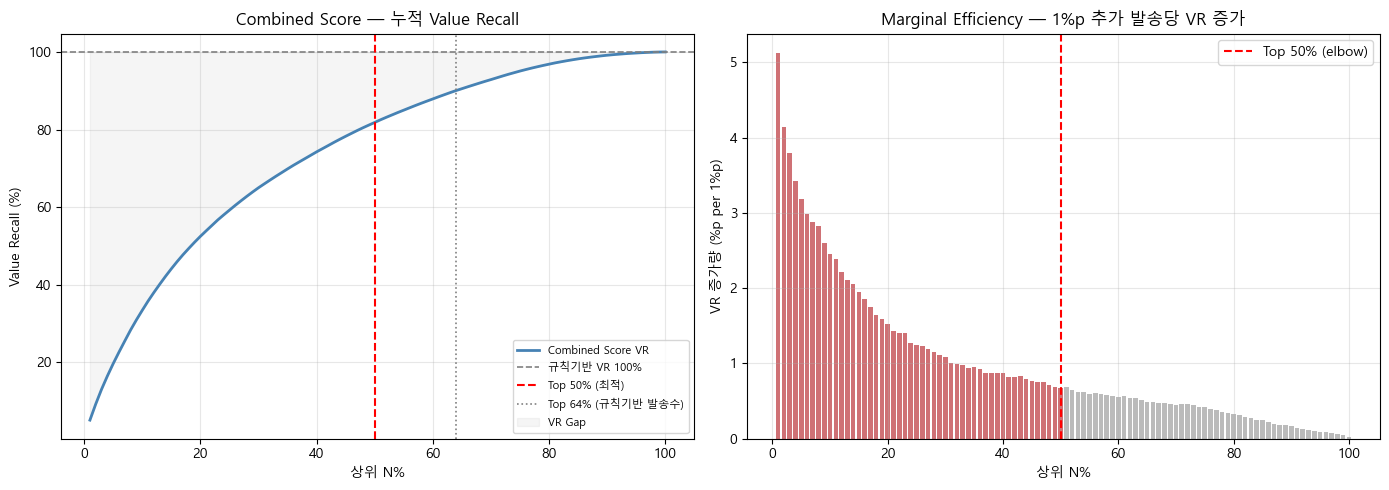

차트 저장 완료


In [32]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 1%p 단위 VR 계산
prev_vr = 0.0
pct_range, vr_curve, marg_curve = [], [], []

for pct in range(1, 101):
    n   = int(len(full) * pct / 100)
    vr  = df_comb.head(n)[df_comb.head(n)['actual']==0]['first_purchase_price'].sum() / TOTAL_CHURN_VAL * 100
    pct_range.append(pct)
    vr_curve.append(vr)
    marg_curve.append(vr - prev_vr)
    prev_vr = vr

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 좌: Cumulative Value Recall
ax1 = axes[0]
ax1.plot(pct_range, vr_curve, color='steelblue', lw=2, label='Combined Score VR')
ax1.axhline(100, color='gray', ls='--', lw=1.2, label=f'규칙기반 VR 100%')
ax1.axvline(50, color='red',    ls='--', lw=1.5, label=f'Top 50% (최적)')
ax1.axvline(64, color='gray',   ls=':',  lw=1.2, label=f'Top 64% (규칙기반 발송수)')
ax1.fill_between(pct_range, vr_curve, 100, alpha=0.08, color='gray', label='VR Gap')
ax1.set_xlabel('상위 N%')
ax1.set_ylabel('Value Recall (%)')
ax1.set_title('Combined Score — 누적 Value Recall')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# 우: Marginal Efficiency
ax2 = axes[1]
colors_bar = ['#C44E52' if p <= 50 else '#aaaaaa' for p in pct_range]
ax2.bar(pct_range, marg_curve, color=colors_bar, alpha=0.8, width=0.8)
ax2.axvline(50, color='red', ls='--', lw=1.5, label='Top 50% (elbow)')
ax2.set_xlabel('상위 N%')
ax2.set_ylabel('VR 증가량 (%p per 1%p)')
ax2.set_title('Marginal Efficiency — 1%p 추가 발송당 VR 증가')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('combined_score_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print('차트 저장 완료')

NameError: name 'dpi150' is not defined

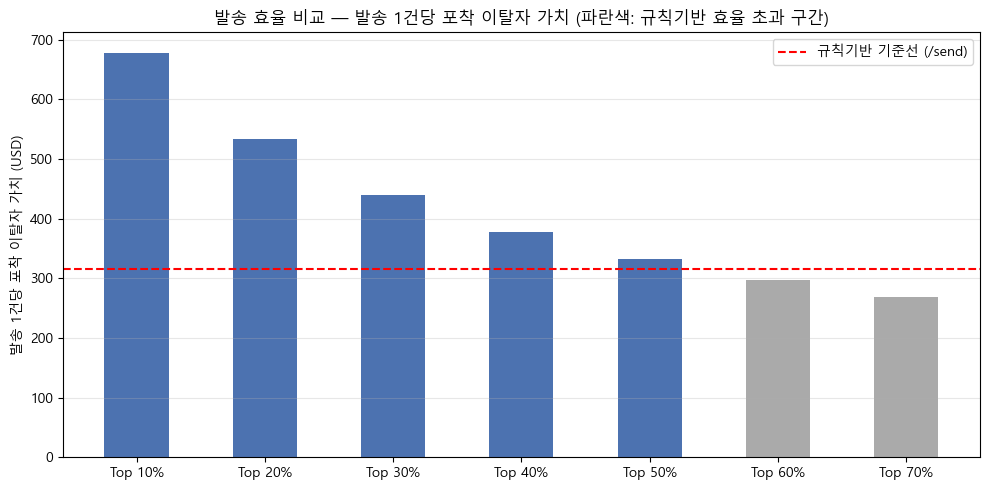

In [34]:
# 발송 효율 비교 차트 (규칙기반 vs ML Top N%)
fig, ax = plt.subplots(figsize=(10, 5))
pct_range2 = list(range(10, 71, 10))
effs = []
for pct in pct_range2:
    n   = int(len(full) * pct / 100)
    vr  = df_comb.head(n)[df_comb.head(n)['actual']==0]['first_purchase_price'].sum() / TOTAL_CHURN_VAL
    effs.append((vr * TOTAL_CHURN_VAL) / n)
labels  = [f'Top {p}%' for p in pct_range2]
colors  = ['#4C72B0' if p <= 50 else '#aaaaaa' for p in pct_range2]
bars = ax.bar(labels, effs, color=colors, width=0.5)
ax.axhline(EFF_RULE, color='red', ls='--', lw=1.5, label=f'규칙기반 기준선 (/send)')
for bar, val in zip(bars, effs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            f'', ha='center', va='bottom', fontsize=9)
ax.set_ylabel('발송 1건당 포착 이탈자 가치 (USD)')
ax.set_title('발송 효율 비교 — 발송 1건당 포착 이탈자 가치 (파란색: 규칙기반 효율 초과 구간)')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('send_efficiency.png', dpi150, bbox_inches='tight')
plt.show()
print('차트 저장 완료')

### 결론 — 최적 타겟 기준: Top 50%

| 지표 | 규칙기반 | ML Top 50% | 개선 |
|---|---|---|---|
| 발송 수 | 214,188명 | **166,062명** | **-22.5% (-48,126명)** |
| Value Recall | 100% | **81.8%** | -18.2%p |
| 발송 효율 | $314.8/send | **$332.3/send** | **+5.6% (1.06x)** |

**Top 50%를 선택하는 이유:**
1. **효율배수 1x 마지노선**: Top 50%까지는 send당 포착 가치가 규칙기반보다 높음 (1.06x),
   Top 60%부터 역전(0.94x) — Marginal Efficiency 그래프상 뚜렷한 단일 꺾임(elbow)은
   보이지 않으나, 규칙기반 대비 우위/열위가 갈리는 지점은 명확히 50~60% 사이로 확인됨
2. **발송 22.5% 절감**: 48,126명에 대한 CRM 비용(쿠폰·발송비)을 절감하면서
   이탈자 가치의 81.8% 유지

*(참고: 피처 정의를 재구매 이전 시점으로 제약한 이후 모델 성능(AUC 0.74→0.66)이
하락했고, 이에 따라 Value Recall(83.7→81.8%)·발송효율(1.08x→1.06x)도 소폭 하락했다.
다만 "Top 50%가 최적"이라는 결론 자체와 22.5% 발송 절감은 변하지 않았다.)*

### 6-3. [추가 분석] 쿠폰 CRM 근거 — 이탈자 vs 재구매자 구매금액 검증

> **DA 연결 분석**
>
> CRM에 쿠폰을 포함하려면 이탈자가 실제로 가격에 민감한지 확인이 필요하다.
> 이탈자와 재구매자의 첫 구매금액 차이가 DA 효과크기 기준(r = 0.1)을 충족하는지 검증한다.

In [35]:
from scipy.stats import mannwhitneyu
import pandas as pd

#feature_df = pd.read_pickle('feature_df.pkl')

churners     = feature_df[feature_df['repurchase']==0]['first_purchase_price']
repurchasers = feature_df[feature_df['repurchase']==1]['first_purchase_price']

n1, n2 = len(repurchasers), len(churners)
u_stat, p_mw = mannwhitneyu(repurchasers, churners, alternative='two-sided')
r_rb = 1 - (2 * u_stat) / (n1 * n2)   # rank-biserial r (DA와 동일 기준)

print('=== 이탈자 vs 재구매자 첫 구매금액 비교 ===')
print(f'이탈자   평균: ${churners.mean():.2f}  (n={n2:,}명)')
print(f'재구매자 평균: ${repurchasers.mean():.2f}  (n={n1:,}명)')
print(f'차이: ${repurchasers.mean() - churners.mean():.2f}')
print()
print(f'Mann-Whitney U  p-value : {p_mw:.4f}')
print(f'Rank-biserial r         : {r_rb:.3f}')
print(f'DA 효과크기 기준(|r|≥0.1): {"✅ 충족" if abs(r_rb) >= 0.1 else "❌ 미달"}')
print()
print('해석: 이탈자는 재구매자 대비 평균 $61.9 낮은 가격대 상품을 구매.')
print('      가격 민감도 차이가 통계적으로 유의하며 효과크기 기준 충족.')
print('      → 쿠폰 포함 CRM이 이탈자 재유입 수단으로 정당화된다.')

=== 이탈자 vs 재구매자 첫 구매금액 비교 ===
이탈자   평균: $314.69  (n=214,257명)
재구매자 평균: $376.63  (n=117,868명)
차이: $61.94

Mann-Whitney U  p-value : 0.0000
Rank-biserial r         : -0.112
DA 효과크기 기준(|r|≥0.1): ✅ 충족

해석: 이탈자는 재구매자 대비 평균 $61.9 낮은 가격대 상품을 구매.
      가격 민감도 차이가 통계적으로 유의하며 효과크기 기준 충족.
      → 쿠폰 포함 CRM이 이탈자 재유입 수단으로 정당화된다.


### 6-4. CRM 비용 브레이크이븐 분석

> **가정**
> - CRM 전환율: **3%** (DA에서 산출한 세그먼트별 CRM 효과 +3%p 기반)
> - CRM 비용: 쿠폰 = 평균 구매금액($314.7) × 쿠폰율
> - 발송 비용은 쿠폰만 고려 (이메일·SMS 발송 비용 제외)
>
> **순이익 = 이탈자 가치 회수 − CRM 발송 비용**
> - 이탈자 가치 회수 = VR × 전체 이탈자 가치 × 전환율
> - CRM 발송 비용 = 발송 수 × (평균 구매금액 × 쿠폰율)
>
> **브레이크이븐**: 쿠폰율이 이 지점을 넘으면 ML Top 50%의 순이익이 규칙기반을 초과

=== 브레이크이븐 분석 (전환율 3% 고정) ===
브레이크이븐 쿠폰단가: $7.65/send
브레이크이븐 쿠폰율:   2.4% (평균 구매금액 $314.7 기준)

   쿠폰율       쿠폰단가         규칙기반 순이익     ML Top50% 순이익      차이(ML-규칙)
----------------------------------------------------------------------
  1.0%  $    3.15          +1.349M           +1.132M        -0.217M
  2.4%  $    7.55          +0.405M           +0.400M        -0.005M ← 브레이크이븐
  3.0%  $    9.44          +0.001M           +0.087M        +0.086M
  5.0%  $   15.73          -1.347M           -0.958M        +0.389M
 10.0%  $   31.47          -4.718M           -3.571M        +1.146M
 15.0%  $   47.20          -8.088M           -6.184M        +1.904M
 20.0%  $   62.94         -11.458M           -8.797M        +2.661M


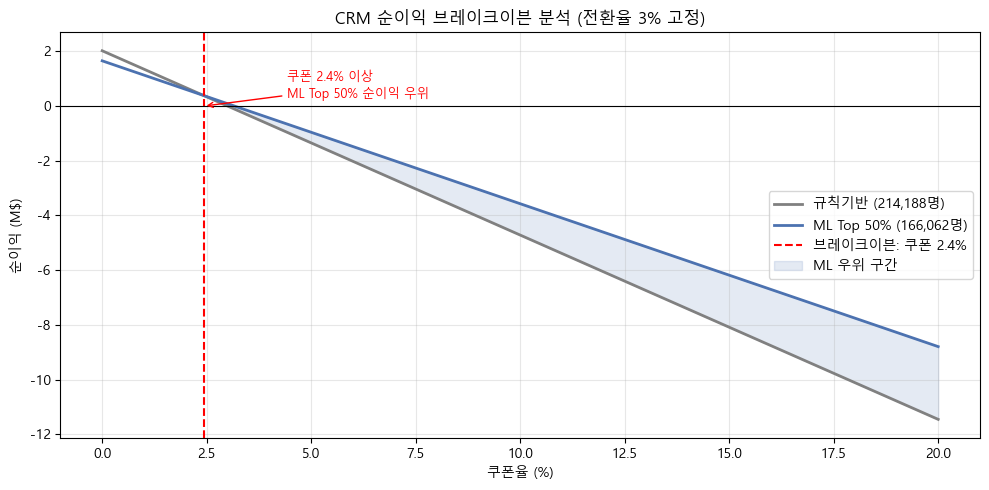


결론: 쿠폰 2.4% 이상 → ML Top 50%가 비용 절감 + 순이익 모두 우위


In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# ── 파라미터 ──────────────────────────────────────────────────
CR          = 0.03                # CRM 전환율 (DA 기반 3%)
AVG_PRICE   = full[full['actual']==0]['first_purchase_price'].mean()  # $314.7
TOTAL_CV    = full[full['actual']==0]['first_purchase_price'].sum()   # $67.4M

N_RULE  = 214188;  VR_RULE = 1.000
N_ML    = 166062;  VR_ML = float(result_df.loc[result_df['Top_%']=='50%', 'Value_Recall'].values[0].rstrip('%')) / 100

# ── 브레이크이븐 쿠폰단가 계산 ──────────────────────────────
# (VR_rule - VR_ml) * TOTAL_CV * CR = (N_rule - N_ml) * c
be_cost = (VR_RULE - VR_ML) * TOTAL_CV * CR / (N_RULE - N_ML)
be_rate = be_cost / AVG_PRICE * 100

print(f'=== 브레이크이븐 분석 (전환율 {CR*100:.0f}% 고정) ===')
print(f'브레이크이븐 쿠폰단가: ${be_cost:.2f}/send')
print(f'브레이크이븐 쿠폰율:   {be_rate:.1f}% (평균 구매금액 ${AVG_PRICE:.1f} 기준)')
print()

# ── 쿠폰율별 순이익 계산 ──────────────────────────────────────
coupon_rates = np.linspace(0, 0.20, 200)
net_rule, net_ml = [], []

for cr_rate in coupon_rates:
    c = AVG_PRICE * cr_rate
    net_rule.append(VR_RULE * TOTAL_CV * CR - N_RULE * c)
    net_ml.append(  VR_ML   * TOTAL_CV * CR - N_ML   * c)

# ── 시나리오 테이블 ───────────────────────────────────────────
print(f'{"쿠폰율":>6}  {"쿠폰단가":>9}  {"규칙기반 순이익":>15}  {"ML Top50% 순이익":>16}  {"차이(ML-규칙)":>13}')
print('-' * 70)
for rate in sorted(set([0.01, 0.03, 0.05, 0.10, 0.15, 0.20, round(be_rate/100, 3)])):
    c     = AVG_PRICE * rate
    n_r   = VR_RULE * TOTAL_CV * CR - N_RULE * c
    n_m   = VR_ML   * TOTAL_CV * CR - N_ML   * c
    mark  = ' ← 브레이크이븐' if abs(rate - be_rate/100) < 0.002 else ''
    print(f'{rate*100:>5.1f}%  ${c:>8.2f}  {n_r/1e6:>+14.3f}M  {n_m/1e6:>+15.3f}M  {(n_m-n_r)/1e6:>+12.3f}M{mark}')

# ── 시각화 ────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(coupon_rates*100, [v/1e6 for v in net_rule],
        color='gray', lw=2, label='규칙기반 (214,188명)')
ax.plot(coupon_rates*100, [v/1e6 for v in net_ml],
        color='#4C72B0', lw=2, label='ML Top 50% (166,062명)')

ax.axvline(be_rate, color='red', ls='--', lw=1.5,
           label=f'브레이크이븐: 쿠폰 {be_rate:.1f}%')
ax.axhline(0, color='black', lw=0.8, ls='-')

ax.fill_between(coupon_rates*100,
                [v/1e6 for v in net_ml],
                [v/1e6 for v in net_rule],
                where=[m > r for m, r in zip(net_ml, net_rule)],
                alpha=0.15, color='#4C72B0', label='ML 우위 구간')

ax.annotate(f'쿠폰 {be_rate:.1f}% 이상\nML Top 50% 순이익 우위',
            xy=(be_rate, 0), xytext=(be_rate+2, 0.3),
            fontsize=9, color='red',
            arrowprops=dict(arrowstyle='->', color='red'))

ax.set_xlabel('쿠폰율 (%)')
ax.set_ylabel('순이익 (M$)')
ax.set_title(f'CRM 순이익 브레이크이븐 분석 (전환율 {CR*100:.0f}% 고정)')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('crm_breakeven.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'\n결론: 쿠폰 {be_rate:.1f}% 이상 → ML Top 50%가 비용 절감 + 순이익 모두 우위')